In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

In [2]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

Across sessions:
- prediction accuracy for each barrier in each condition
- prediction accuracy over the course of sessions

In [5]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_20004\3207939509.py:17: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


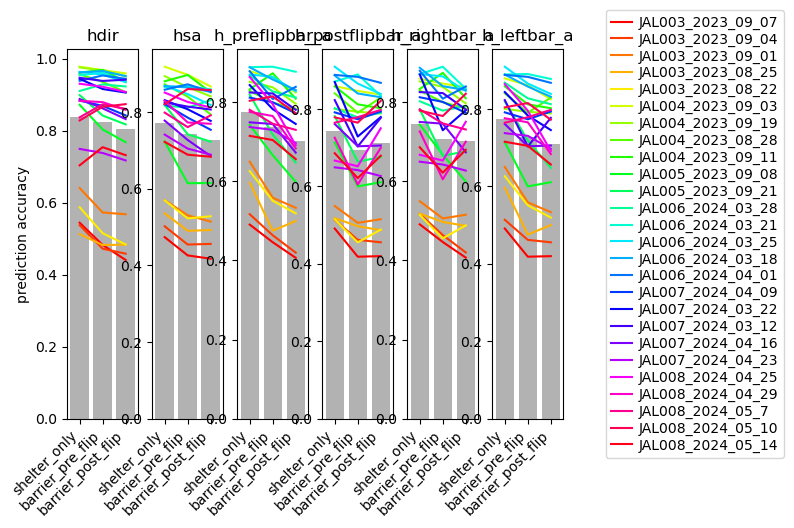

In [6]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [10, 5]
for idx, a in enumerate(all_angles):
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[a])))))
    axs[idx].plot(conditions,pa[a].T)
    axs[idx].bar(conditions,np.mean(pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
axs[idx].legend(all_names,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_allsesh_'+settings+'.png'))

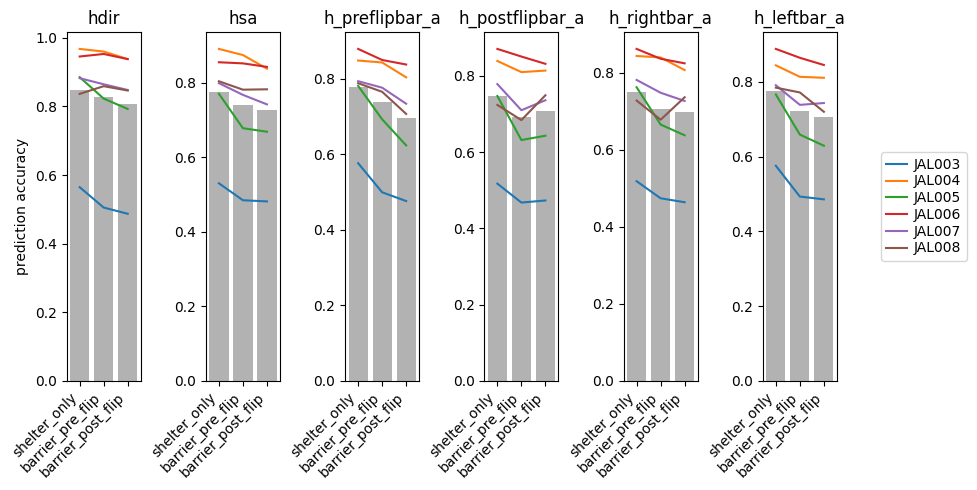

In [9]:
'''Plot the predicton accuracy for all sessions for the standard angles - BUT average by mouse'''
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [10, 5]
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_pa = {}
for key in pa.keys():
    if key not in m_pa:
        m_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(all_angles):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_pa[a][m_idx,:] = np.mean(pa[a][this_mouse,:], axis=0)
    axs[idx].plot(conditions,m_pa[a].T)
    axs[idx].bar(conditions,np.mean(m_pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
axs[idx].legend(unique_mouse,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_allmice_'+settings+'.png'))

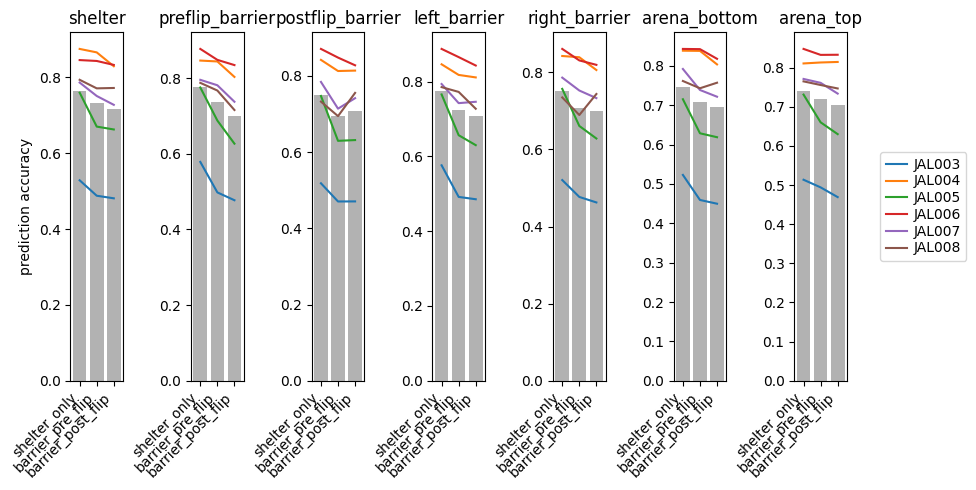

In [10]:
'''Plot the predicton accuracy for all sessions for the standard angles - BUT average by mouse'''
fig, axs = plt.subplots(1,len(avg_pa.keys()))
plt.rcParams['figure.figsize'] = [10, 5]
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_avg_pa = {}
for key in avg_pa.keys():
    if key not in m_avg_pa:
        m_avg_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(avg_pa.keys()):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_avg_pa[a][m_idx,:] = np.mean(avg_pa[a][this_mouse,:], axis=0)
    axs[idx].plot(conditions,m_avg_pa[a].T)
    axs[idx].bar(conditions,np.mean(m_avg_pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
axs[idx].legend(unique_mouse,
                loc='center left', 
                bbox_to_anchor=(1.5, .5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
axs[0].set_ylabel('prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('avgpa_allmice_'+settings+'.png'))

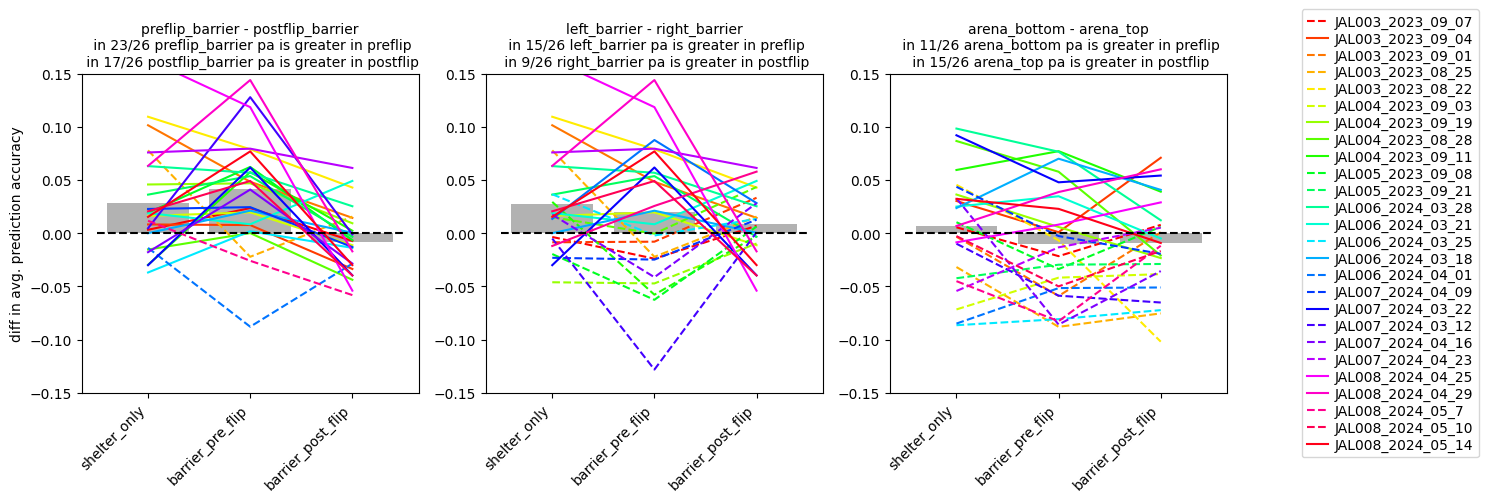

In [11]:
''' Plot the difference in pa (averaged over an area) for two goals'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = avg_pa[c[0]] - avg_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(avg_pa[c[0]])))))
    for p in diff:
        if p[1] > 0: # p[2]:
            axs[idx].plot(conditions,p)
        else:
            axs[idx].plot(conditions,p,'--')
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(avg_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in avg. prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVGpa_diff_allsesh_'+settings+'.png'))

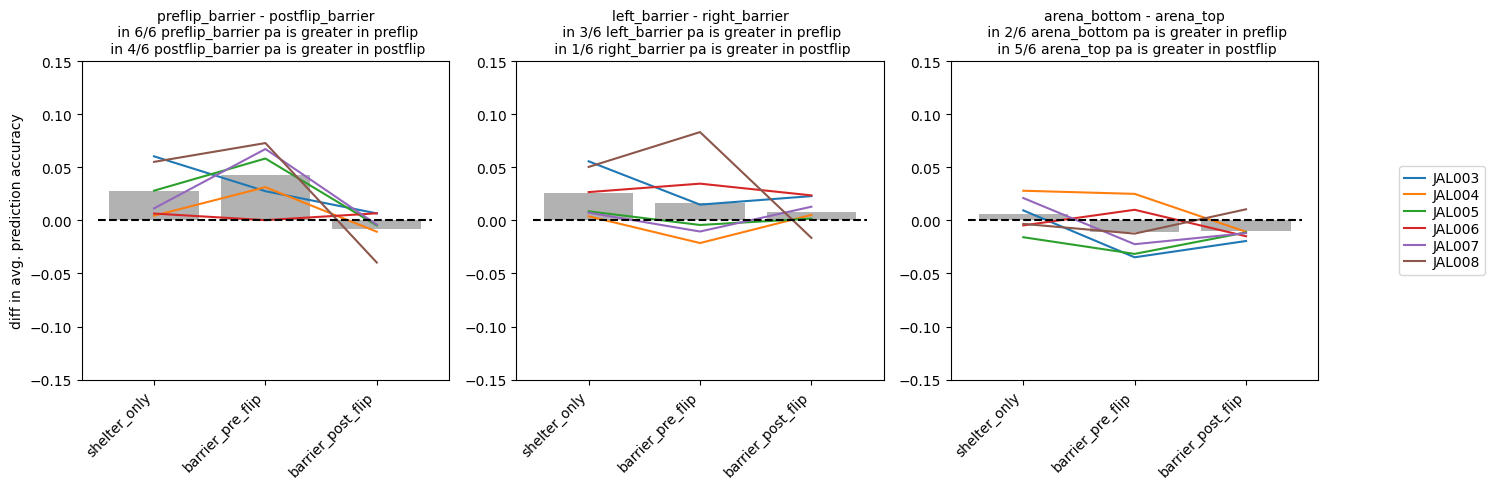

In [12]:
''' Plot the difference in pa (averaged over an area) for two goals - BUT averaged per mouse'''
combos = [['preflip_barrier','postflip_barrier'],['left_barrier', 'right_barrier'], ['arena_bottom', 'arena_top']]

plt.rcParams['figure.figsize'] = [15, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = m_avg_pa[c[0]] - m_avg_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    # axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(m_avg_pa[c[0]])))))
    for p in diff:
        axs[idx].plot(conditions,p)
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(m_avg_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(m_avg_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in avg. prediction accuracy')
axs[idx].legend(unique_mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('AVGpa_diff_allmice_'+settings+'.png'))

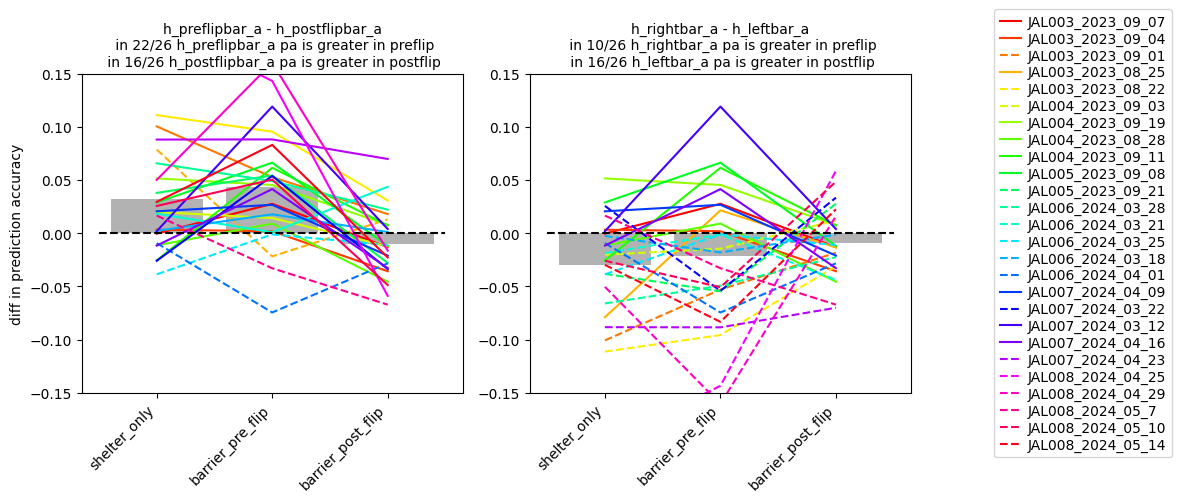

In [13]:
''' Plot the difference in pa for two goals'''
combos = [['h_preflipbar_a','h_postflipbar_a'],['h_rightbar_a','h_leftbar_a']]

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = pa[c[0]] - pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    axs[idx].set_prop_cycle(plt.cycler('color', plt.cm.hsv(np.linspace(0, 1, len(pa[c[0]])))))
    for p in diff:
        if p[1] > 0: #p[2]:
            axs[idx].plot(conditions,p)
        else:
            axs[idx].plot(conditions,p,'--')
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    # axs[idx].set_title(c[0] + ' - ' + c[1]  +  
    #                    '\n in ' + str(np.sum(diff[:,1]>diff[:,2])) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip',
    #                    fontsize = 10)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in prediction accuracy')
axs[idx].legend(all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'.png'))

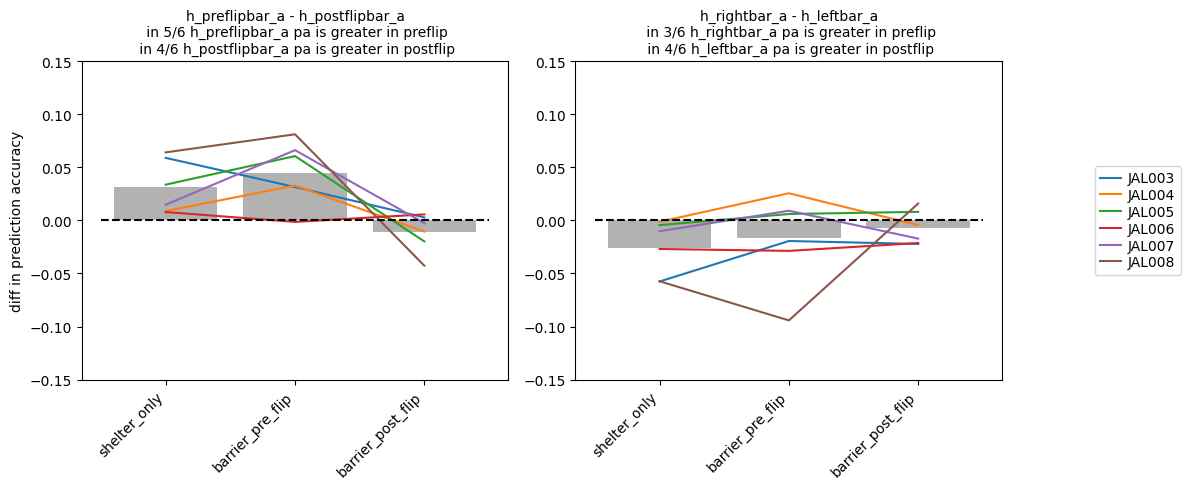

In [14]:
''' Plot the difference in pa for two goals - but now by mouse'''
combos = [['h_preflipbar_a','h_postflipbar_a'],['h_rightbar_a','h_leftbar_a']]

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,len(combos))

for idx,c in enumerate(combos):
    diff = m_pa[c[0]] - m_pa[c[1]]
    axs[idx].bar(conditions,np.nanmean(diff,axis=0),color = 'k',alpha = .3)
    for p in diff:
        axs[idx].plot(conditions,p)
    axs[idx].plot([-.5,2.5],[0,0],'--k')
    axs[idx].set_title(c[0] + ' - ' + c[1]  +  
                       '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(m_pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
                       '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(m_pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
                       fontsize = 10)
    axs[idx].set_xticks(np.arange(len(conditions)))
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
    axs[idx].set_ylim([-.15,.15])
axs[0].set_ylabel('diff in prediction accuracy')
axs[idx].legend(unique_mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allmice_'+settings+'.png'))

Compare difference in prediction accuracy over time

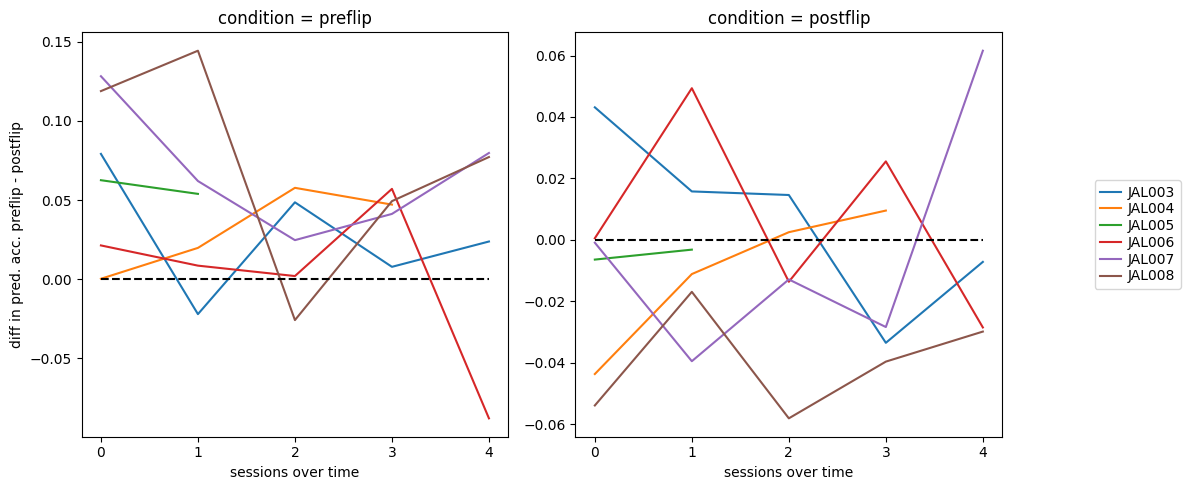

In [51]:
'''Find for each mouse the sessions in order and plot the prediction accuracy'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']
diff = avg_pa['preflip_barrier'] - avg_pa['postflip_barrier']

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,2)

from datetime import datetime
def extract_date(t):
    date_str = t[0].split('_')[1:]
    date_str = '_'.join(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')

for m in mouse:
    this_m = [(c,d) for c,d in zip(all_names,diff[:,1]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[0].plot(values)
    this_m = [(c,d) for c,d in zip(all_names,diff[:,2]) if m in c]
    sorted_m = sorted(this_m, key=extract_date)
    values = [t[1] for t in sorted_m]
    axs[1].plot(values)

axs[0].set_ylabel('diff in pred. acc. preflip - postflip')
axs[0].set_title('condition = preflip')
axs[1].set_title('condition = postflip')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,4],[0,0],'--k')
    axs[i].set_xlabel('sessions over time')
    axs[i].set_xticks(np.arange(0,5,1))

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))

In [84]:
barrier_sesh_by_mouse = {'JAL003': ['2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                         'JAL004': ['2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                         'JAL005': ['2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                         'JAL006': ['2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                         'JAL007': ['2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                         'JAL008': ['2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

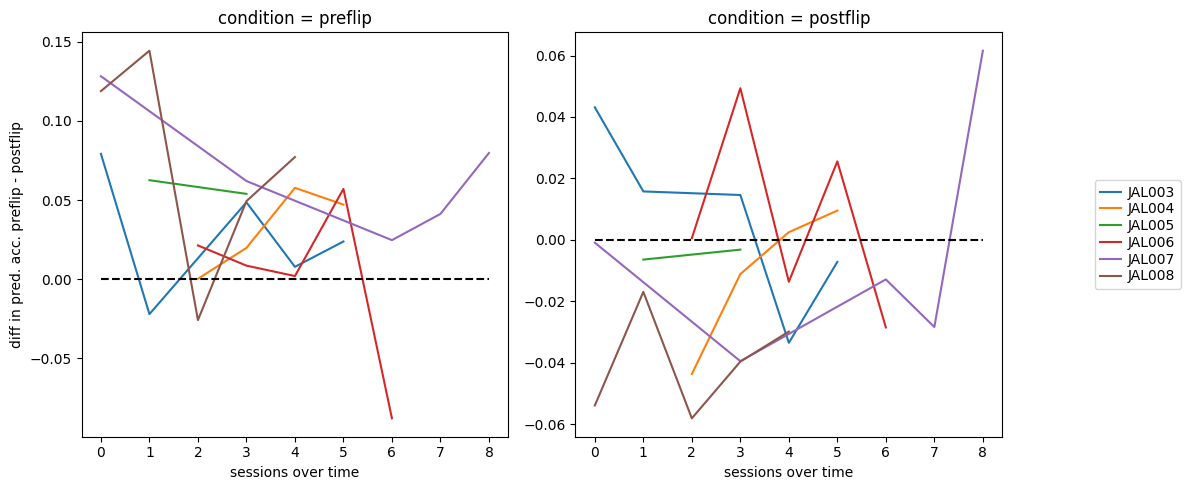

In [86]:
'''Find for each mouse the sessions in order and plot the prediction accuracy,
labeled by which barrier sessions this is'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']
diff = avg_pa['preflip_barrier'] - avg_pa['postflip_barrier']

plt.rcParams['figure.figsize'] = [12, 5]
fig, axs = plt.subplots(1,2)

for m in mouse:
    this_m = [c for c in all_names if m in c]
    this_m_idx = []
    for sesh in this_m:
        this_m_idx.append([i for i,m in enumerate(barrier_sesh_by_mouse[m]) if m in sesh][0])
    this_m_idx = np.array(this_m_idx)
    sort_idx = np.argsort(this_m_idx)
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,1]) if m in c]) # preflip
    axs[0].plot(this_m_idx[sort_idx],this_m_val[sort_idx])
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,2]) if m in c]) # postflip
    axs[1].plot(this_m_idx[sort_idx],this_m_val[sort_idx])

axs[0].set_ylabel('diff in pred. acc. preflip - postflip')
axs[0].set_title('condition = preflip')
axs[1].set_title('condition = postflip')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,8],[0,0],'--k')
    axs[i].set_xlabel('sessions over time')
    axs[i].set_xticks(np.arange(0,9,1))

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))